In [121]:
# For development
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [125]:
from functools import partial
from pathlib import Path
from glob import glob

import pandas as pd
import matplotlib.pyplot as plt

# for metadata extraction (if not embedded)
from datetime import datetime
import h5py
import ast 

from mxtreme.config import Config
from mxtreme import io, utils
from mxtreme.recording import Recording
import mxtreme.visualizations as viz
import mxtreme.paths as paths

# Preprocessing
from mxtreme.pipeline import Pipeline
from mxtreme import extract, clean

# Burst detection
from mxtreme.bursting import BurstDetector
from mxtreme.params import BurstDetectParams, BurstFeatureParams

# Analysis
from mxtreme.identity import CultureID, CultureSelector
from mxtreme.analysis import generate_report


### 1. Configure the output directory using the `mxtreme.toml` file

Edit `mxtreme.toml` to define the root directory for mxtreme output.

In [7]:
config = Config.from_toml("mxtreme.toml")
config.preprocessed_dir.resolve()

PosixPath('/Users/cgrass04/Code/mxt_cait_test_out/preprocessed')

### 2. Define the raw file paths and metadata 

Using data from two experiments: StimRemoval and WaveTraining

In [8]:
RAW_DATA_DIR = Path("/run/user/1001/gvfs/smb-share:server=rstore.it.tufts.edu,share=levinlab_braintrix$/Experimental Data")

Old experiments don't have metadata stored in them, so we must manually provide this information in the form of:

```python
metadata = {"Exp ID": "May2025_Wave", "Chip ID": "M07459", "Plate date": 250512, "DIV": 0, "Conditions":[[2,0]]}

# Phase spec by event tags ...
metadata["Phases"] = {
    "starts": {"pre": "pre_recording_start", "train": "closed_loop_start", "post": "post_recording_start"},
    "end": "end_experiment",
}
# ... or by time in minutes from the first frame:
metadata["Phases"] = {"starts": {"pre": 0, "train": 20, "post": 40}, "end": 60}
```

In [9]:
wave_training_paths = glob(str(RAW_DATA_DIR / "May2025_Wave" / "*" / "*" / "*" / "well*"/ "*.h5"))

In [10]:
%%script false --no-raise-error # skips execution
wt_metadata_dicts = {}

for h5_path_str in wave_training_paths:

    h5_path = Path(h5_path_str)

    wt_metadata_dicts[h5_path_str] = {} # init empty metadata dict for this h5 file

    wt_metadata_dicts[h5_path_str]["Exp ID"] = "WaveTraining" # however we want to identify this experimental batch
    wt_metadata_dicts[h5_path_str]["Chip ID"] = h5_path.parts[-5]
    wt_metadata_dicts[h5_path_str]["Plate date"] = "250403"
    wt_metadata_dicts[h5_path_str]["DIV"] = (datetime.strptime(h5_path.parts[-4], "%y%m%d") - datetime.strptime(wt_metadata_dicts[h5_path_str]["Plate date"], "%y%m%d")).days # recording date - plate date to get DIV 
    wt_metadata_dicts[h5_path_str]["Phases"] = {"starts": {"pre": "pre_recording_start", "train": "closed_loop_start", "post": "post_recording_start"},
                                            "end": "end_experiment",
                                        }
    
    # Extract experimental conditions
    with h5py.File(h5_path, 'r') as f:

        closed_loop_args = f[f'/assay/closed_loop_args'][:][0]
        closed_loop_args = closed_loop_args.decode('utf-8').strip()

        left_stim_list = ast.literal_eval(closed_loop_args.split('--left-type')[-1].split('--')[0])
        right_stim_list = ast.literal_eval(closed_loop_args.split('--right-type')[-1].split('--')[0])

        left_stim = int(left_stim_list)
        right_stim = int(right_stim_list)

    wt_metadata_dicts[h5_path_str]["Conditions"] = [[left_stim,right_stim]]

    print(wt_metadata_dicts[h5_path_str])
    print()

In [11]:
stim_removal_paths = glob(str(RAW_DATA_DIR / "stim_removal" / "DIV*_stim_removal" / "*" / "*" / "*" / "well*"/ "*.h5"))

In [12]:
%%script false --no-raise-error # skips execution
sr_metadata_dicts = {}

for h5_path_str in stim_removal_paths:

    h5_path = Path(h5_path_str)

    sr_metadata_dicts[h5_path_str] = {} # init empty metadata dict for this h5 file

    sr_metadata_dicts[h5_path_str]["Exp ID"] = "StimRemoval" # however we want to identify this experimental batch
    sr_metadata_dicts[h5_path_str]["Chip ID"] = h5_path.parts[-5]
    sr_metadata_dicts[h5_path_str]["Plate date"] = "240703"
    sr_metadata_dicts[h5_path_str]["DIV"] = (datetime.strptime(h5_path.parts[-4], "%y%m%d") - datetime.strptime(sr_metadata_dicts[h5_path_str]["Plate date"], "%y%m%d")).days # recording date - plate date to get DIV 
    sr_metadata_dicts[h5_path_str]["Phases"] = {"starts": {"pre": 0, "train": 20, "post": 40}, "end": 60} # no event tags, so manually split into 20 minute segments 
    sr_metadata_dicts[h5_path_str]["Conditions"] = [[0,2]] # all stim removal experiments were trained for left bursting 

    print(sr_metadata_dicts[h5_path_str])
    print()

### 3. Define a preprocessing pipeline

In [13]:
%%script false --no-raise-error # skips execution
pipeline = Pipeline([
    clean.normalize_time,                                     # frames -> start at 0
    clean.dac_to_voltage,                                     # DAC units -> V
    clean.remove_positive_deflections,                        # keep negative spikes
    partial(clean.spike_filter, amp_thresh=2e-5),             # drop < 20 µV  
    partial(clean.remove_spurious_spikes, refractory_period=0.002),
    clean.remove_spurious_channels,                           # drop unmapped channels
    clean.build_channel_map,                                  # needed before binning
    partial(clean.remove_stim_frames, post_stim_period=0.05), # drop stim-window spikes
    partial(clean.bin_spikes, bin_size=0.01),                 # 10 ms bins
])

### 4. Extract the data and run the pipeline to clean and transform it

In [14]:
%%script false --no-raise-error # skips execution
# Wave training

wt_paths = []

for h5_path in wave_training_paths:
    data = extract.extract(h5_path, metadata=wt_metadata_dicts[h5_path])
    paths = pipeline.run(data, datastore=config.preprocessed_dir)

    wt_paths.extend(paths)

In [15]:
%%script false --no-raise-error # skips execution
# Stim removal

sr_paths = []

for h5_path in stim_removal_paths:
    data = extract.extract(h5_path, metadata=sr_metadata_dicts[h5_path])
    paths = pipeline.run(data, datastore=config.preprocessed_dir)

    sr_paths.extend(paths)


### 5. Filter data using `registry.csv`

Data from paper 1 is a subset of WaveTraining and StimRemoval experiments that have experimental conditions of either [0,2] or [2,0].

In [22]:
# Load registry.csv

reg = pd.read_csv(config.registry_path)


In [25]:
targets = [[0, 2], [2, 0]]
mask = reg["conditions"].apply(lambda s: ast.literal_eval(s) in targets)
filtered = reg[mask]

In [ ]:
# Group by culture and count the number of recordings (DIV) per culture
counts = (
    filtered.groupby(["exp_id", "chip", "well"])["div"]
    .nunique()
    .reset_index(name="n_div")
)

counts

,exp_id,chip,well,n_div
0,StimRemoval,M07471,0,3
1,StimRemoval,M07471,2,3
2,StimRemoval,M07480,0,10
3,StimRemoval,M07480,1,10
4,StimRemoval,M07480,2,10
5,StimRemoval,M07480,3,10
6,StimRemoval,M07480,4,10
7,StimRemoval,M07480,5,10
8,WaveTraining,M07459,0,7
9,WaveTraining,M07459,1,7


In [29]:
# Filter out cultures with fewer than 3 recordings 
culture_set = counts[counts["n_div"] > 3]
culture_set

,exp_id,chip,well,n_div
2,StimRemoval,M07480,0,10
3,StimRemoval,M07480,1,10
4,StimRemoval,M07480,2,10
5,StimRemoval,M07480,3,10
6,StimRemoval,M07480,4,10
7,StimRemoval,M07480,5,10
8,WaveTraining,M07459,0,7
9,WaveTraining,M07459,1,7
10,WaveTraining,M07459,2,8
11,WaveTraining,M07462,0,4


### 6. Detect bursts 

In [79]:
npz_paths = []
for i,culture in culture_set.iterrows():
    culture_paths = sorted(config.preprocessed_dir.glob(f"{culture["exp_id"]}/{culture["chip"]}/well{culture["well"]}/DIV*_exp_data.npz"))
    npz_paths.extend(culture_paths)
    print(f"found {len(culture_paths)} recordings")
    # for p in npz_paths:
    #     print(" ", p.relative_to(config.preprocessed_dir))

found 10 recordings
found 10 recordings
found 10 recordings
found 10 recordings
found 10 recordings
found 10 recordings
found 7 recordings
found 7 recordings
found 8 recordings
found 4 recordings
found 8 recordings


In [ ]:
# The better way to select cultures but requires restarting the kernel to run
# selector = CultureSelector(cultures=[
#     CultureID(str(row.exp_id), str(row.chip), str(row.well))
#     for row in culture_set.itertuples()
# ])

# recordings = resolve_recordings(selector, config)
# npz_paths = recordings.npz

# print(f"found {len(npz_paths)} recordings")

In [76]:
detect_params = BurstDetectParams()      # defaults: n=300, noise_thresh=0.05, burst_thresh=0.15, min_dist_bins=30, pass in as arguments to change
feature_params = BurstFeatureParams()    # defaults: onset_thresh_pct=0.1, offset_thresh_pct=0.05, pass in as arguments to change

print(detect_params)
print(feature_params)

BurstDetectParams(n=300, noise_thresh=0.05, burst_thresh=0.15, min_dist_bins=30)
BurstFeatureParams(onset_thresh_pct=0.1, offset_thresh_pct=0.05)


In [80]:
summary = []
for npz in npz_paths:
    data = io.load_preprocessed(npz)

    # Recording reconstructs its phases from the spec embedded in the npz -- nothing to declare here.
    rec = Recording(0, data)

    # temporary fix for any spike data that is not sorted already (this occurred in one recording where the last spike was out of place - likely a buffer issue when finishing writing the file)
    rec.spike_data = utils.sort_spike_data(rec.spike_data)

    # Passing burst_data_dir= refreshes the per-experiment burst log automatically after each
    # of detection and feature extraction (each stamps its own timestamp).
    bursts = BurstDetector(detect_params).detect(rec, burst_data_dir=config.burst_data_dir)
    bursts.extract_features(rec, feature_params, burst_data_dir=config.burst_data_dir)

    csv_path = io.save_burst_data(bursts, config.burst_data_dir, rec)

    df = bursts.to_dataframe()
    summary.append({
        "recording": f"{rec.exp_id}/{rec.chip}/well{rec.well}/DIV{rec.DIV}",
        "phases": ",".join(rec.phases.names),
        "n_bursts": len(bursts),
        "n_network": int((df["kind"] == "network").sum()),
        "n_mini": int((df["kind"] == "mini").sum()),
        "n_ignored": bursts.n_ignored,
    })

pd.DataFrame(summary)

Detecting bursts | StimRemoval/M07480/well0/DIV29 | method=isi_rate
------------------------------------------------------------
Detected 445 burst(s): 445 network
Burst log updated -> ../../../mxt_cait_test_out/burst_data/StimRemoval_burst_log.csv
Extracting features for 445 burst(s) | StimRemoval/M07480/well0/DIV29
Features computed | 0 burst(s) flagged ignore
Burst log updated -> ../../../mxt_cait_test_out/burst_data/StimRemoval_burst_log.csv
Burst data saved to: ../../../mxt_cait_test_out/burst_data/StimRemoval/M07480/well0/DIV29_240703_M07480_StimRemoval_well0_burst_data.csv
Detecting bursts | StimRemoval/M07480/well0/DIV30 | method=isi_rate
------------------------------------------------------------
Detected 564 burst(s): 564 network
Burst log updated -> ../../../mxt_cait_test_out/burst_data/StimRemoval_burst_log.csv
Extracting features for 564 burst(s) | StimRemoval/M07480/well0/DIV30
Features computed | 0 burst(s) flagged ignore
Burst log updated -> ../../../mxt_cait_test_out/

,recording,phases,n_bursts,n_network,n_mini,n_ignored
0,StimRemoval/M07480/well0/DIV29,"pre,train,post",445,445,0,0
1,StimRemoval/M07480/well0/DIV30,"pre,train,post",564,564,0,0
2,StimRemoval/M07480/well0/DIV33,"pre,train,post",266,266,0,1
3,StimRemoval/M07480/well0/DIV34,"pre,train,post",951,728,223,0
4,StimRemoval/M07480/well0/DIV35,"pre,train,post",454,454,0,0
...,...,...,...,...,...,...
89,WaveTraining/M07462/well2/DIV36,"pre,train,post",50,50,0,0
90,WaveTraining/M07462/well2/DIV39,"pre,train,post",16,16,0,0
91,WaveTraining/M07462/well2/DIV40,"pre,train,post",14,14,0,0
92,WaveTraining/M07462/well2/DIV41,"pre,train,post",9,9,0,0


In [94]:
npz_path = npz_paths[89]

In [95]:
# Visualize a single culture

rec = Recording(0, io.load_preprocessed(npz_path))
burst_df = io.load_burst_data(io._burst_csv_path(config.burst_data_dir, rec)).to_dataframe()

Left: 551, Right: 352


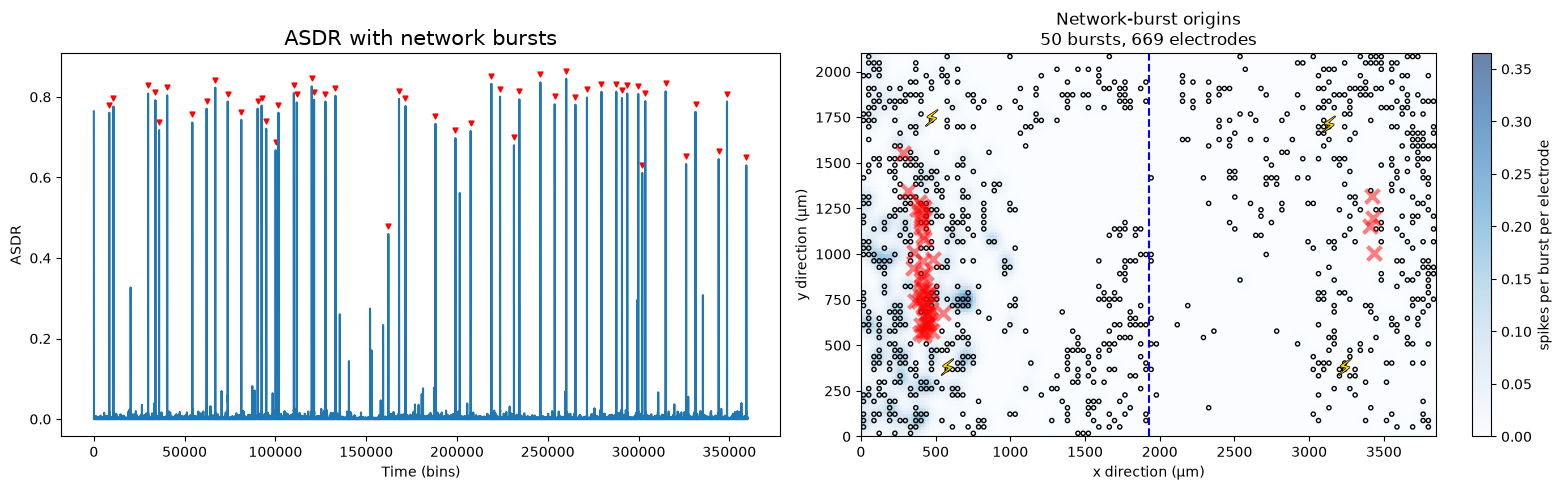

In [96]:
rec = Recording(0, io.load_preprocessed(npz_path))
burst_df = io.load_burst_data(io._burst_csv_path(config.burst_data_dir, rec)).to_dataframe()

fig, (ax_asdr, ax_mea) = plt.subplots(1, 2, figsize=(16, 5))
viz.plot_bursts_on_asdr(rec, burst_df, ax=ax_asdr, title="ASDR with network bursts") # can pass zoom=(start, stop) as an optional parameter to zoom in on the ASDR plot
viz.plot_origin_heatmap(rec, burst_df, ax=ax_mea, title="Network-burst origins")
plt.tight_layout()
plt.show()

### 7. Analysis report

Including learning curves using pre-phase of the recordings

In [112]:
# Report sections
SECTIONS = ("overview", "activity", "bursting", "stimulation", "performance")

In [113]:
group = CultureSelector(cultures=[
    CultureID(str(row.exp_id), str(row.chip), str(row.well))
    for row in culture_set.itertuples()
])

In [ ]:
generate_report(
    group, config,
    sections=SECTIONS,
    output_path=config.analysis_dir / "reports" / "paper1_data.pdf",
)

Loading existing summary from ../../../mxt_cait_test_out/analysis/activity/StimRemoval/M07480/well0/StimRemoval_M07480_well0_channel_activity_summary.csv
Loading existing summary from ../../../mxt_cait_test_out/analysis/activity/StimRemoval/M07480/well1/StimRemoval_M07480_well1_channel_activity_summary.csv
Loading existing summary from ../../../mxt_cait_test_out/analysis/activity/StimRemoval/M07480/well2/StimRemoval_M07480_well2_channel_activity_summary.csv
Loading existing summary from ../../../mxt_cait_test_out/analysis/activity/StimRemoval/M07480/well3/StimRemoval_M07480_well3_channel_activity_summary.csv
Loading existing summary from ../../../mxt_cait_test_out/analysis/activity/StimRemoval/M07480/well4/StimRemoval_M07480_well4_channel_activity_summary.csv
Loading existing summary from ../../../mxt_cait_test_out/analysis/activity/StimRemoval/M07480/well5/StimRemoval_M07480_well5_channel_activity_summary.csv
Loading existing summary from ../../../mxt_cait_test_out/analysis/activity/W

PosixPath('../../../mxt_cait_test_out/analysis/reports/paper1_data.pdf')